In [2]:
import practicalSPARQL
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
import bqplot as bq
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import networkx as nx
from itertools import combinations

In [3]:
df = pd.read_csv('full_image_data_feb_25.csv')
books = pd.read_csv('full_book_data_feb_25.csv')

In [4]:
# Assuming 'book_id' is the column to join on
df['printer'] = df['book'].map(books.set_index('book')['printers'])
df['publisher'] = df['book'].map(books.set_index('book')['publishers'])

In [5]:
# Define the target cks values
target_cks = [
'CK_Tropics',
'CK_Polar Circles',
'CK_Parallels',
'CK_Five Zones',
'CK_Distances between Small Circles'
]

In [6]:
#filtering the df to get the images of the target cks with all their data + printing counts
#(this is why only filter is not enough: we need all the cks that are in other rows with double images values)

# Step 1: Filter the DataFrame for rows where 'cks' is in the target_cks list
filtered_df_target_cks = df[df['cks'].isin(target_cks)]

# Step 2: Get the unique 'images' values associated with the target cks
images_with_target_cks = filtered_df_target_cks['images'].unique()

# Step 3: Filter the original DataFrame to include all rows that have these images
filtered_df = df[df['images'].isin(images_with_target_cks)]

# filtered_df

In [7]:
unique_counts = pd.concat([
    df[['images', 'cluster_name', 'cks', 'place', 'printer', 'publisher']].nunique().rename('df'),
    filtered_df[['images', 'cluster_name', 'cks', 'place', 'printer', 'publisher']].nunique().rename('filtered_df')
], axis=1)

print(unique_counts)

                 df  filtered_df
images        20540          973
cluster_name   3563          119
cks             168           15
place            42           39
printer         166          149
publisher       155          138


In [8]:
print(filtered_df['cks'].dropna().unique())


['CK_Tropics' 'CK_Parallels' 'CK_Five Zones' 'CK_Populated Earth'
 'CK_Seven Climate Zones' 'CK_Terraqueous Globe'
 'CK_Distances between Small Circles' 'CK_Geometry for Geometry'
 'CK_Armillary Sphere' 'CK_Polar Circles' 'CK_Zodiac' 'CK_08 Spheres'
 'CK_Multiple Celestial Circles' 'CK_Right and Oblique Sphere'
 'CK_Movement of the Sun']


In [11]:
#Extract unique values
unique_clusters = filtered_df['cluster_name'].dropna().unique()

# Save to CSV
# pd.Series(unique_clusters).to_csv('/Users/nogashlomi/projects/Image_data/visual_tags/2.2.csv', index=False, header=False)

In [12]:
visual_tags = pd.read_excel('/Users/nogashlomi/projects/Image_data/visual_tags/VT_2.4.xlsx')

In [13]:
# Get unique values
visual_tags_clusters = set(visual_tags['cluster_name'].unique())
filtered_df_clusters = set(filtered_df['cluster_name'].unique())

# Compare
only_in_visual_tags = visual_tags_clusters - filtered_df_clusters
only_in_filtered_df = filtered_df_clusters - visual_tags_clusters
in_both = visual_tags_clusters & filtered_df_clusters

# Print results
print("Unique cluster names only in visual_tags:")
print(sorted(only_in_visual_tags))

print("\nUnique cluster names only in filtered_df:")
print(sorted(only_in_filtered_df))

# print("\nCluster names present in both:")
# print(sorted(in_both))


Unique cluster names only in visual_tags:
[]

Unique cluster names only in filtered_df:
[]


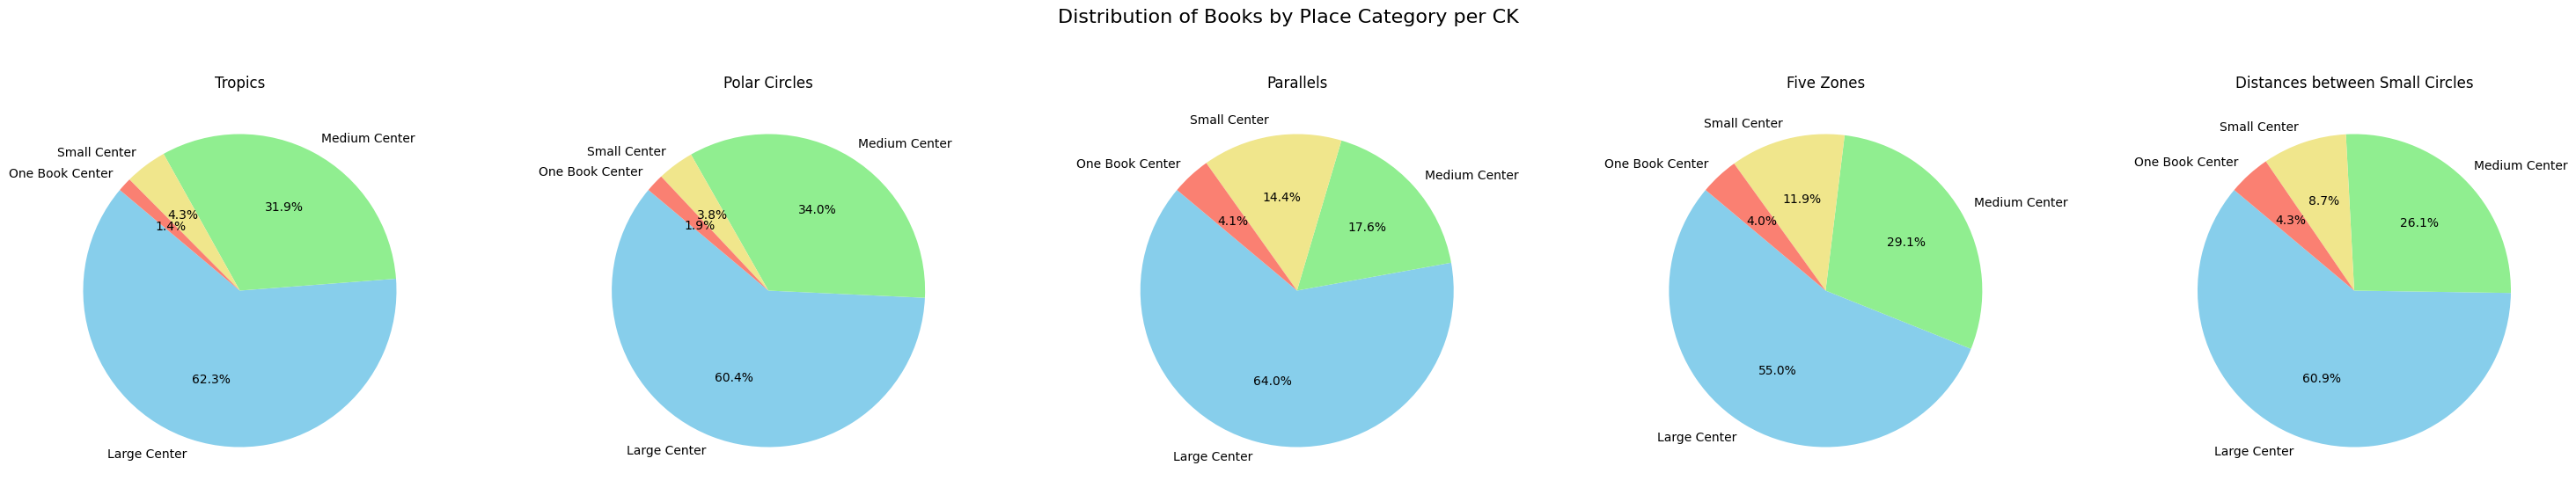

In [14]:
# === Assume filtered_df already filtered to target_cks ===

target_cks = [
'CK_Tropics',
'CK_Polar Circles',
'CK_Parallels',
'CK_Five Zones',
'CK_Distances between Small Circles'
]


# Drop duplicates per (CK, book) — this is the key line
unique_ck_books = df.drop_duplicates(subset=['cks', 'book'])

# Prepare consistent color map
place_categories = unique_ck_books['place_category'].dropna().unique().tolist()
color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki', 'plum', 'orange', 'lightcoral', 'lightsteelblue']
category_color_map = {
    cat: color_palette[i % len(color_palette)] for i, cat in enumerate(place_categories)
}

# Setup plots
num_cks = len(target_cks)
fig, axes = plt.subplots(1, num_cks, figsize=(6 * num_cks, 6))
if num_cks == 1:
    axes = [axes]

# Group by CK after deduplication
grouped = unique_ck_books.groupby('cks')

# Loop through CKs and plot pies
for ax, ck in zip(axes, target_cks):
    if ck in grouped.groups:
        ck_df = grouped.get_group(ck)
        counts = ck_df.groupby('place_category')['book'].nunique().sort_values(ascending=False)
        colors = [category_color_map.get(cat, 'gray') for cat in counts.index]

        ax.pie(
            counts,
            labels=counts.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=140
        )
        ax.set_title(ck.replace('CK_', '').replace('_', ' '), fontsize=12)
    else:
        ax.set_title(f'{ck}: No Data')
        ax.axis('off')

# Final layout
plt.suptitle('Distribution of Books by Place Category per CK', fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.9])
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/2.4.png', dpi=300)

plt.show()

Number of Unique Books per CK Group, All Books, and Filtered Books:
               CK_Tropics  CK_Polar Circles  CK_Parallels  CK_Five Zones  \
year_interval                                                              
1470-1489             0.0               0.0             2              4   
1490-1509             4.0               0.0            11             26   
1510-1529             5.0               0.0            19             21   
1530-1549             5.0               3.0            28             39   
1550-1569            23.0              23.0            61             71   
1570-1589            18.0              17.0            46             52   
1590-1609            10.0               7.0            39             41   
1610-1629             4.0               3.0            14             20   
1630-1650             0.0               0.0             2              4   

               CK_Distances between Small Circles  All Books  Filtered Books  
year_interval   

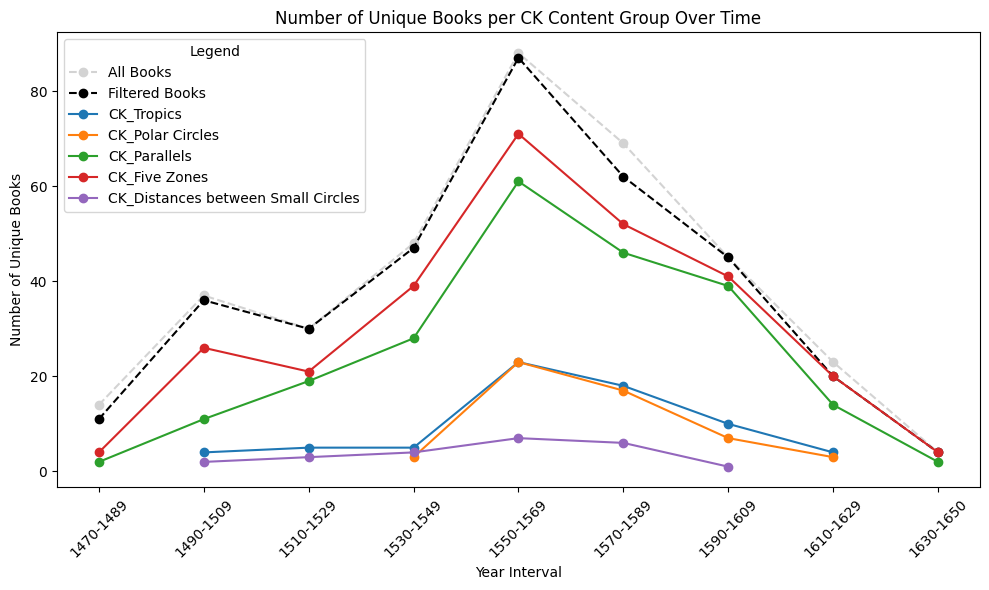

In [15]:

# Define target CK tags
target_cks = [
'CK_Tropics',
'CK_Polar Circles',
'CK_Parallels',
'CK_Five Zones',
'CK_Distances between Small Circles'
]

# ✅ 1. Total books per year_interval (from full books df)
all_books_count = books.groupby('year_interval', observed=False)['book'].nunique()

# ✅ 2. Total books per year_interval (from filtered_df)
filtered_books_count = df.groupby('year_interval', observed=False)['book'].nunique()

# ✅ Use the full timeline from all_books_count
intervals = all_books_count.index.astype(str)

# ✅ 3. Book counts per CK from filtered_df
book_counts = {
    keyword: (
        df[df['cks'] == keyword]
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .to_dict()
    )
    for keyword in target_cks
}

# ✅ 4. Create unified DataFrame
book_counts_df = pd.DataFrame(book_counts).reindex(all_books_count.index).fillna(0)
book_counts_df['All Books'] = all_books_count
book_counts_df['Filtered Books'] = filtered_books_count.reindex(all_books_count.index).fillna(0)

# ✅ 5. Print the summary table
print("Number of Unique Books per CK Group, All Books, and Filtered Books:")
print(book_counts_df)

# ✅ 6. Plotting
plt.figure(figsize=(10, 6))

# Plot total number of books (full dataset)
plt.plot(intervals, book_counts_df['All Books'].values, label='All Books', marker='o', color='lightgrey', linestyle='--')

# Plot number of filtered books
plt.plot(intervals, book_counts_df['Filtered Books'].values, label='Filtered Books', marker='o', color='black', linestyle='--')

# Plot each CK content group (only where values are non-zero)
for keyword in target_cks:
    values = book_counts_df[keyword].values
    non_zero_intervals = [intervals[i] for i, val in enumerate(values) if val > 0]
    non_zero_values = [val for val in values if val > 0]

    if non_zero_values:
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=keyword)

# ✅ 7. Final touches
plt.title('Number of Unique Books per CK Content Group Over Time')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend(title='Legend')
plt.tight_layout()

# ✅ 8. Save the figure
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/xxx.png', dpi=300)

# ✅ 9. Show the plot
plt.show()


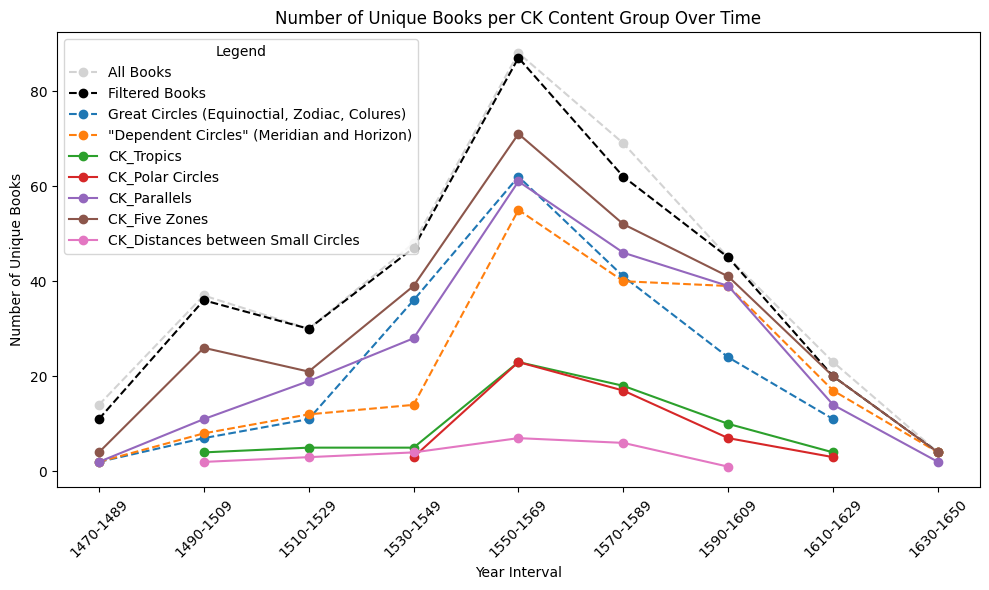

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------
# Define CK tags
# ------------------------------

# Individual (main) CK tags
main_ck_tags = ['CK_Tropics',
'CK_Polar Circles',
'CK_Parallels',
'CK_Five Zones',
'CK_Distances between Small Circles'
               ]

# Combined CK tag groups – fill in as needed
combined_ck_groups = {
    'Great Circles (Equinoctial, Zodiac, Colures)': ['CK_Equinoctial', 'CK_Zodiac', 'CK_Colures'],
    '"Dependent Circles" (Meridian and Horizon)': ['CK_Meridian', 'CK_Horizon'],
    # Add more combinations here:
    # 'Your Label Here': ['CK_X', 'CK_Y', 'CK_Z'],
}

# ------------------------------
# Book counts
# ------------------------------

# 1. Total unique books per interval (from full book list)
all_books_count = books.groupby('year_interval', observed=False)['book'].nunique()

# 2. Total unique books per interval (from filtered dataset)
filtered_books_count = df.groupby('year_interval', observed=False)['book'].nunique()

# 3. Unique book counts for each combined CK group
combined_books_counts = {
    label: (
        df[df['cks'].isin(ck_list)]
        .groupby('year_interval')['book']
        .nunique()
    )
    for label, ck_list in combined_ck_groups.items()
}

# 4. Unique book counts for each individual CK tag
book_counts = {
    keyword: (
        df[df['cks'] == keyword]
        .groupby('year_interval')['book']
        .nunique()
    )
    for keyword in main_ck_tags
}

# ------------------------------
# Assemble final DataFrame
# ------------------------------

book_counts_df = pd.DataFrame(book_counts).reindex(all_books_count.index).fillna(0)
book_counts_df['All Books'] = all_books_count
book_counts_df['Filtered Books'] = filtered_books_count.reindex(all_books_count.index).fillna(0)

# Add combined CK group data to DataFrame
for label, series in combined_books_counts.items():
    book_counts_df[label] = series.reindex(all_books_count.index).fillna(0)

# ------------------------------
# Plotting
# ------------------------------

plt.figure(figsize=(10, 6))
intervals = all_books_count.index.astype(str)

# Helper function: Plot only non-zero values
def plot_non_zero(series, label, **kwargs):
    non_zero = series[series > 0]
    if not non_zero.empty:
        plt.plot(non_zero.index.astype(str), non_zero.values, label=label, marker='o', **kwargs)

# Plot total book lines
plot_non_zero(book_counts_df['All Books'], 'All Books', color='lightgrey', linestyle='--')
plot_non_zero(book_counts_df['Filtered Books'], 'Filtered Books', color='black', linestyle='--')

# Plot each combined CK group
for label in combined_ck_groups.keys():
    plot_non_zero(book_counts_df[label], label, linestyle='--')

# Plot individual CKs
for keyword in main_ck_tags:
    plot_non_zero(book_counts_df[keyword], keyword)

# Final plot settings
plt.title('Number of Unique Books per CK Content Group Over Time')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend(title='Legend')
plt.tight_layout()

# Save the figure
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/2.4_num_books_cks.png', dpi=300)

plt.show()



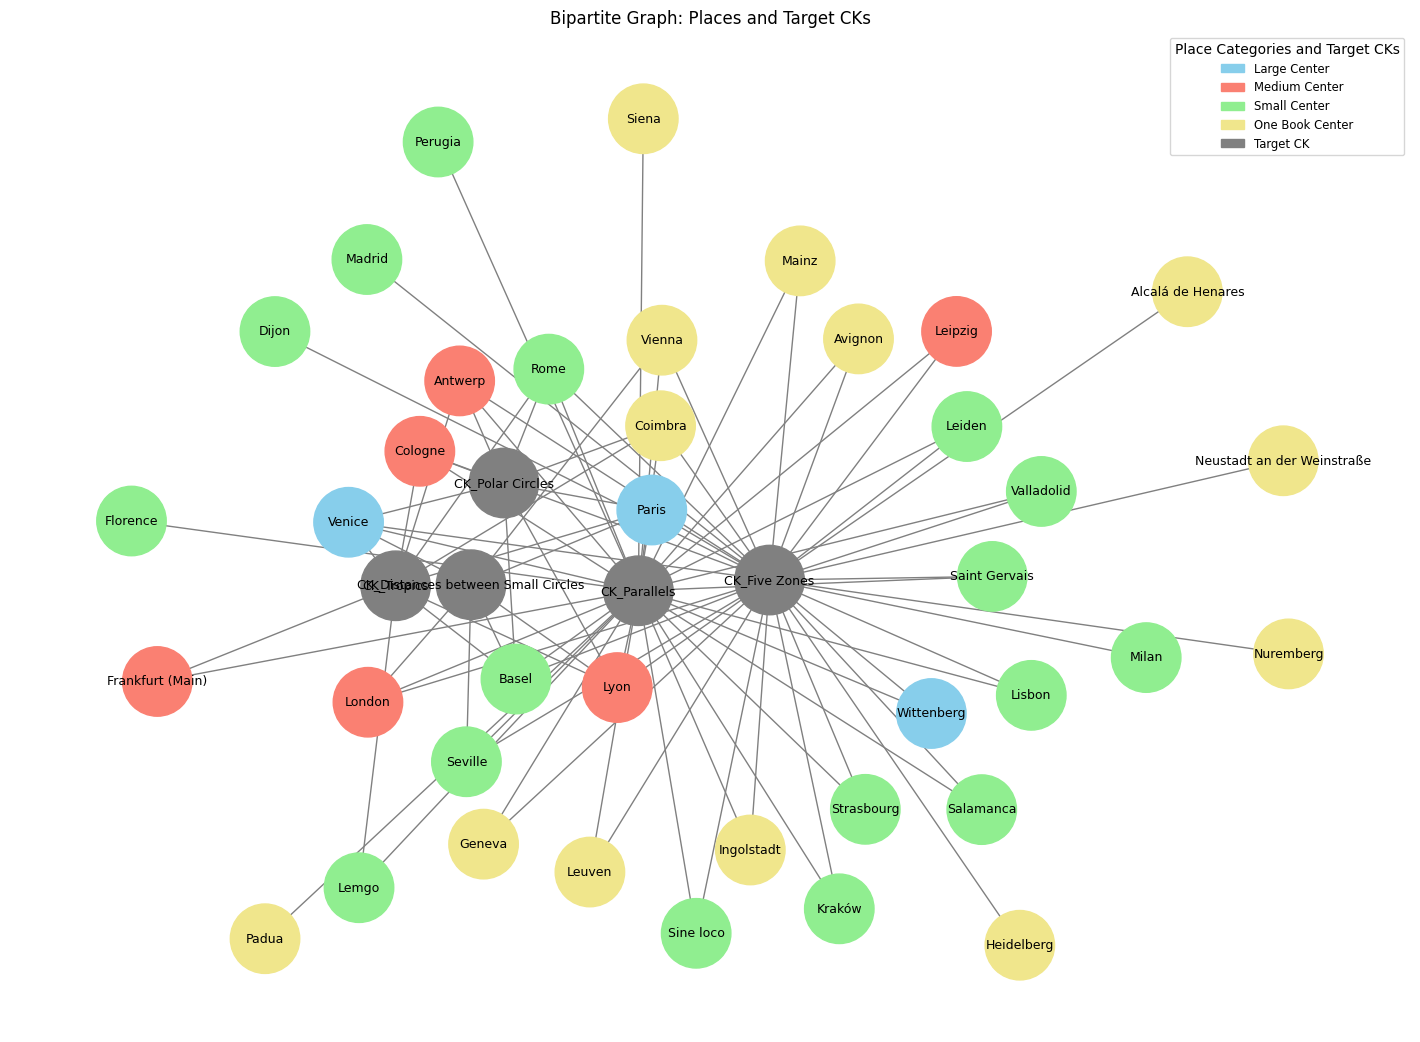

In [36]:
# target CKs list
target_cks = [
'CK_Tropics',
'CK_Polar Circles',
'CK_Parallels',
'CK_Five Zones',
'CK_Distances between Small Circles'
]

# Use filtered_df instead of visual_df
places = df['place'].dropna().unique().tolist()

edges = []

for place in places:
    place_data = df[df['place'] == place]

    # Add edges only between place and target CK if place_data contains that CK
    for cks in target_cks:
        if (place_data['cks'] == cks).any():
            edges.append((place, cks))

# Unique nodes
places_nodes = list(set(edge[0] for edge in edges))
cks_nodes = list(set(edge[1] for edge in edges))

# Color palette and mapping (places by category)
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
existing_categories = df['place_category'].dropna().unique()
ordered_present_categories = [cat for cat in ordered_categories if cat in existing_categories]

color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
category_color_map = {cat: color for cat, color in zip(ordered_present_categories, color_palette)}

place_color_map = {}
for place in places_nodes:
    cat_series = df[df['place'] == place]['place_category'].dropna()
    category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
    place_color_map[place] = category_color_map.get(category, 'gray')

# Build graph
G = nx.Graph()
G.add_nodes_from(places_nodes, bipartite=0)
G.add_nodes_from(cks_nodes, bipartite=1)
G.add_edges_from(edges)

# Node colors:
node_colors = []
for node in G.nodes():
    if node in places_nodes:
        node_colors.append(place_color_map.get(node, 'gray'))
    else:
        # target CK nodes colored grey
        node_colors.append('gray')

# Draw graph
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=0.8)  # Try 0.8, 1.0, or higher

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=2500,
    font_size=9
)

# Legend
legend_handles = [
    mpatches.Patch(color=category_color_map[cat], label=cat)
    for cat in ordered_present_categories
]
legend_handles.append(mpatches.Patch(color='gray', label='Target CK'))

plt.legend(
    handles=legend_handles,
    title='Place Categories and Target CKs',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)
plt.title("Bipartite Graph: Places and Target CKs")

# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/xxx.png', dpi=300)


plt.show()


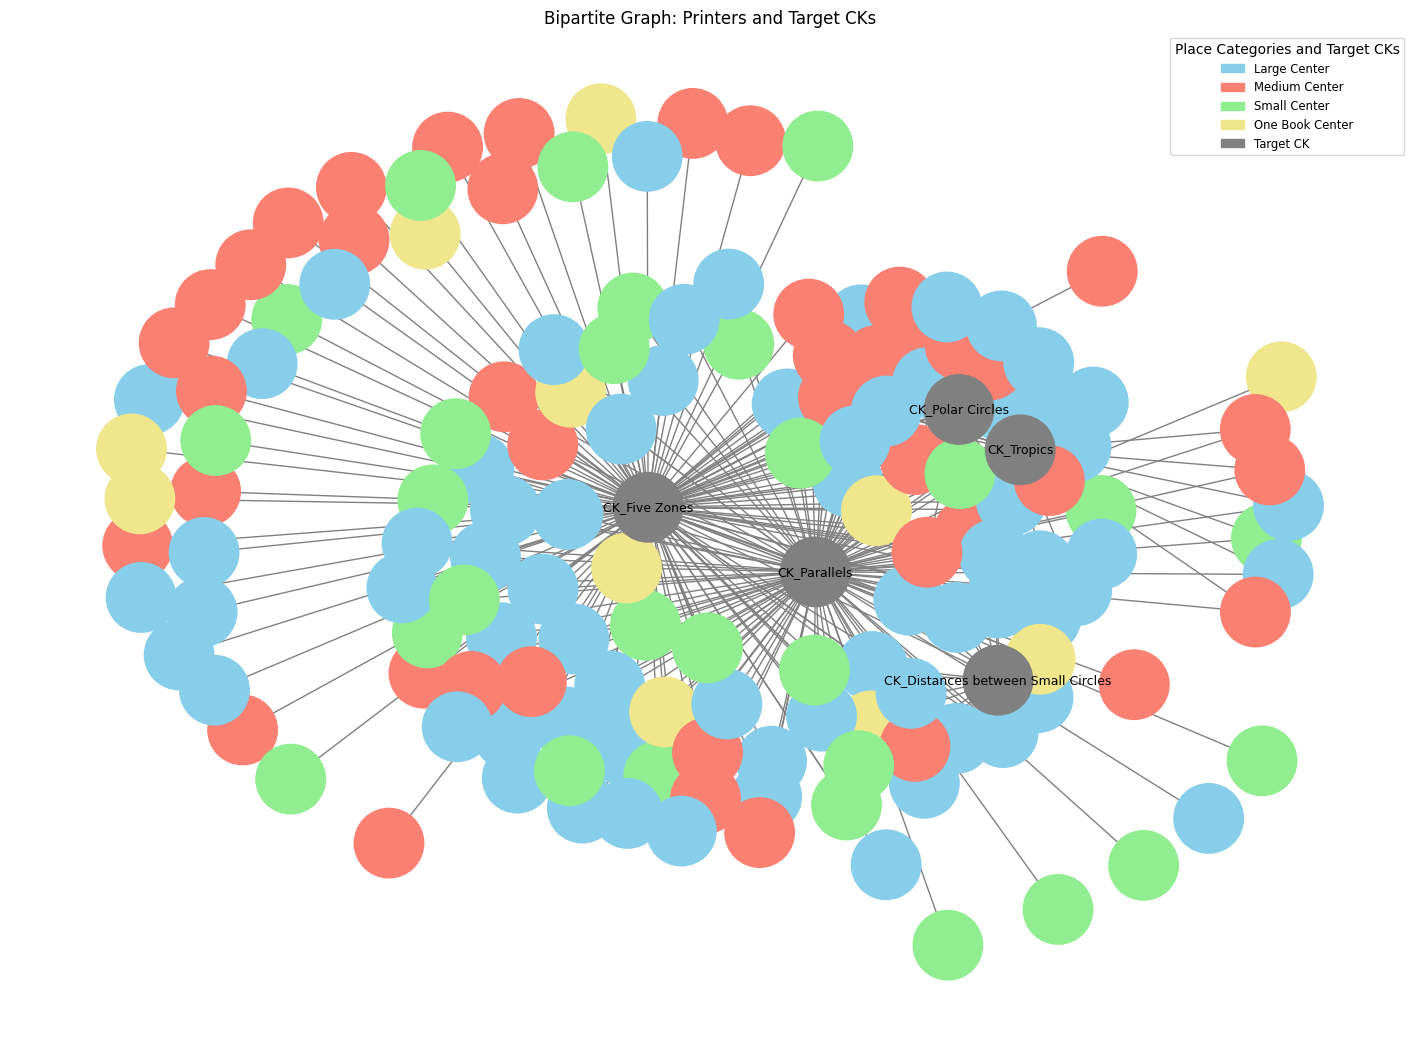

In [37]:
# target CKs list
target_cks = [
'CK_Tropics',
'CK_Polar Circles',
'CK_Parallels',
'CK_Five Zones',
'CK_Distances between Small Circles'
]

# Use filtered_df instead of visual_df
printers = filtered_df['printer'].dropna().unique().tolist()

edges = []

for printer in printers:
    printer_data = filtered_df[filtered_df['printer'] == printer]

    # Add edges only between printer and target CK if printer_data contains that CK
    for cks in target_cks:
        if (printer_data['cks'] == cks).any():
            edges.append((printer, cks))

# Unique nodes
printer_nodes = list(set(edge[0] for edge in edges))
cks_nodes = list(set(edge[1] for edge in edges))

# Color palette and mapping (printers by place category)
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
existing_categories = filtered_df['place_category'].dropna().unique()
ordered_present_categories = [cat for cat in ordered_categories if cat in existing_categories]

color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
category_color_map = {cat: color for cat, color in zip(ordered_present_categories, color_palette)}

printer_color_map = {}
for printer in printer_nodes:
    cat_series = filtered_df[filtered_df['printer'] == printer]['place_category'].dropna()
    category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
    printer_color_map[printer] = category_color_map.get(category, 'gray')

# Build graph
G = nx.Graph()
G.add_nodes_from(printer_nodes, bipartite=0)
G.add_nodes_from(cks_nodes, bipartite=1)
G.add_edges_from(edges)

# Node colors:
node_colors = []
for node in G.nodes():
    if node in printer_nodes:
        node_colors.append(printer_color_map.get(node, 'gray'))
    else:
        # target CK nodes colored grey
        node_colors.append('gray')


# First draw the graph without labels
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    with_labels=False,  # ✅ No labels here
    node_color=node_colors,
    edge_color='gray',
    node_size=2500,
    font_size=9
)


# Then draw labels only for CK nodes
labels = {node: node for node in cks_nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)


# Legend
legend_handles = [
    mpatches.Patch(color=category_color_map[cat], label=cat)
    for cat in ordered_present_categories
]
legend_handles.append(mpatches.Patch(color='gray', label='Target CK'))

plt.legend(
    handles=legend_handles,
    title='Place Categories and Target CKs',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)
plt.title("Bipartite Graph: Printers and Target CKs")

# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/2.2_symbols_printers_network.png', dpi=300)


plt.show()


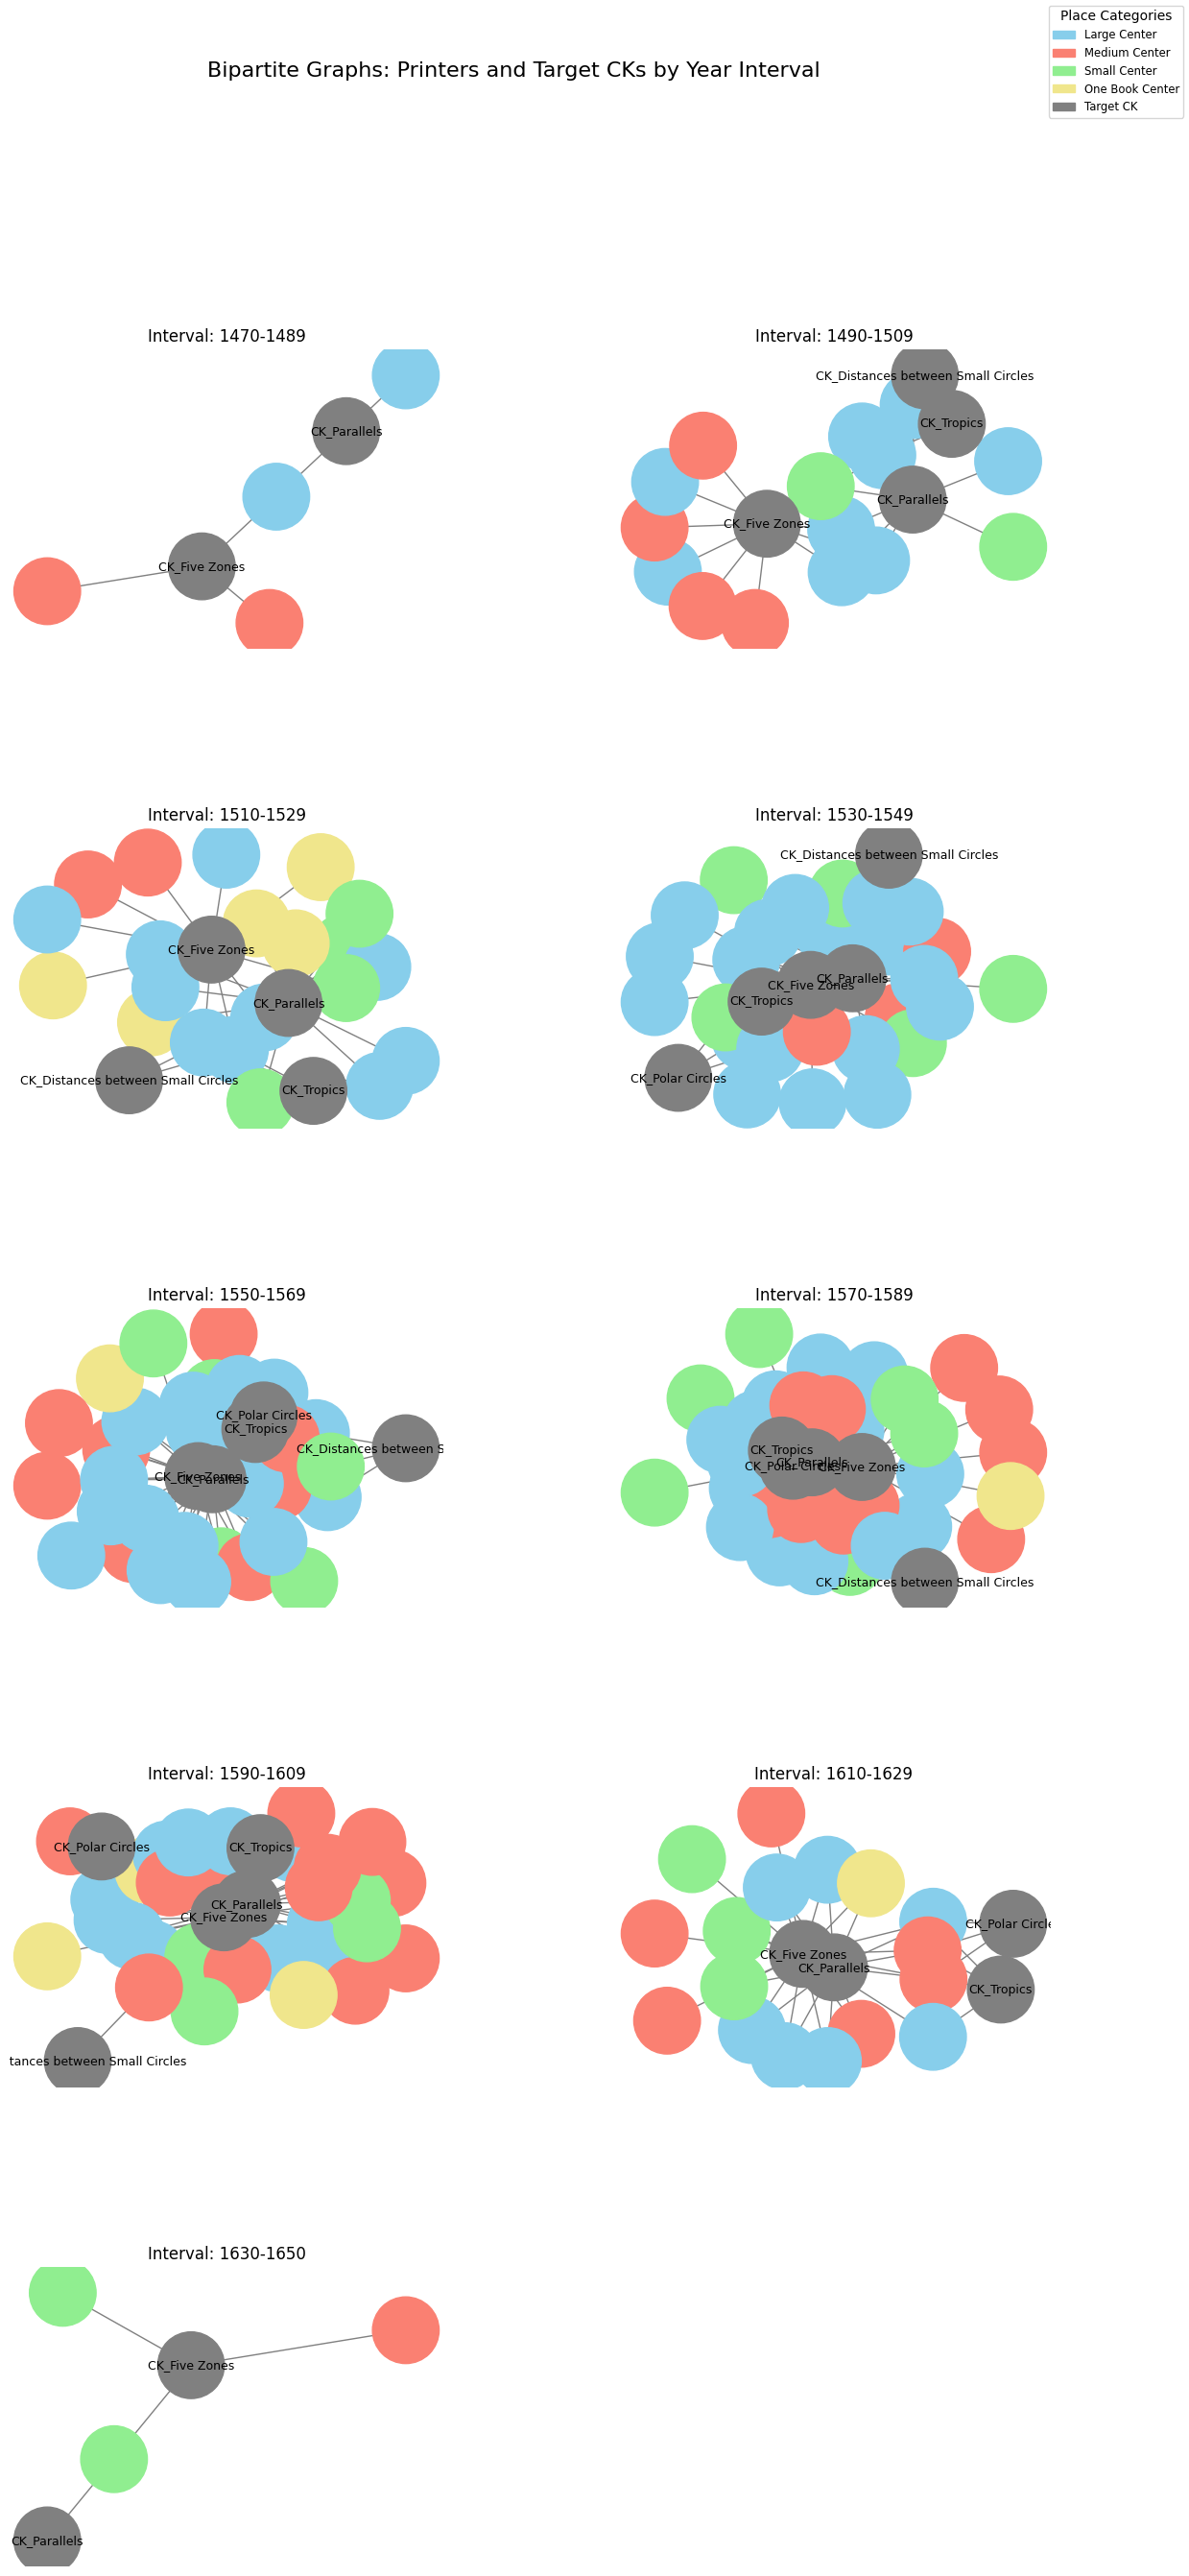

In [38]:


# === Step 0: Define target CKs ===
target_cks = [
'CK_Tropics',
'CK_Polar Circles',
'CK_Parallels',
'CK_Five Zones',
'CK_Distances between Small Circles'
]

# === Step 1: Color settings ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
category_color_map = {cat: color for cat, color in zip(ordered_categories, color_palette)}

# === Step 2: Get year intervals ===
intervals = sorted(filtered_df['year_interval'].dropna().unique())

# === Step 3: Set up figure ===
n_cols = 2
n_rows = (len(intervals) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
axes = axes.flatten()
plt.subplots_adjust(wspace=0.4, hspace=0.6)

# === Step 4: Build graph for each interval ===
for i, interval in enumerate(intervals):
    ax = axes[i]
    df_interval = filtered_df[filtered_df['year_interval'] == interval].copy()
    printers = df_interval['printer'].dropna().unique().tolist()
    edges = []

    for printer in printers:
        printer_data = df_interval[df_interval['printer'] == printer]
        for cks in target_cks:
            if (printer_data['cks'] == cks).any():
                edges.append((printer, cks))

    # Nodes
    printer_nodes = list(set(edge[0] for edge in edges))
    ck_nodes = list(set(edge[1] for edge in edges))

    # Colors
    printer_color_map = {}
    for printer in printer_nodes:
        cat_series = df_interval[df_interval['printer'] == printer]['place_category'].dropna()
        category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
        printer_color_map[printer] = category_color_map.get(category, 'gray')

    node_colors = []
    for node in printer_nodes + ck_nodes:
        if node in printer_nodes:
            node_colors.append(printer_color_map.get(node, 'gray'))
        else:
            node_colors.append('gray')

    # Build graph
    G = nx.Graph()
    G.add_nodes_from(printer_nodes, bipartite=0)
    G.add_nodes_from(ck_nodes, bipartite=1)
    G.add_edges_from(edges)

    pos = nx.spring_layout(G, seed=42, k=0.5)

    # Draw nodes and edges (no labels yet)
    nx.draw(
        G,
        pos,
        with_labels=False,
        node_color=node_colors,
        edge_color='gray',
        node_size=2500,
        ax=ax
    )

    # Only label CK nodes
    labels = {node: node for node in ck_nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, ax=ax)

    ax.set_title(f"Interval: {interval}", fontsize=12)
    ax.axis('off')

# === Step 5: Remove unused axes ===
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# === Step 6: Legend ===
legend_handles = [mpatches.Patch(color=category_color_map[cat], label=cat) for cat in ordered_categories]
legend_handles.append(mpatches.Patch(color='gray', label='Target CK'))

fig.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)

plt.suptitle("Bipartite Graphs: Printers and Target CKs by Year Interval", fontsize=16)
plt.show()


In [43]:
#merge visual tags with filtered_df on cluster_name
visual_df = pd.merge(filtered_df, visual_tags, on='cluster_name')
# visual_df
print(visual_df.columns)

Index(['images', 'cluster_name', 'cks', 'book', 'bid', 'part_or_adaption',
       'part_or_adaption_label', 'type_label', 'custom_identifier', 'place',
       'year', 'flag', 'year_interval', 'place_category', 'latitude',
       'longitude', 'printer', 'publisher', '3D', 'human figures',
       'material object (double lines)', 'multiple moments',
       'multiple perspectives', 'color', 'multiple circles',
       'decorated or stars, tail, scales', 'picture', 'terraqueous globe',
       'diagram', 'small circles representing mutual three dimensional motion',
       'symbol', '3D decoration', '3D main point', 'Unnamed: 3', '3D_geo',
       'human figures_geo', 'material representation', 'diagram_geo',
       'decoration of earth and water', 'full terraqueous globe',
       '3D decoration_fivezones', '3D main idea', 'earth and cosmos',
       'cosmos or earth', 'terraqueous globe_fivezones',
       'motion of the sun two dimensional rep straight line',
       'motion of the sun two dime

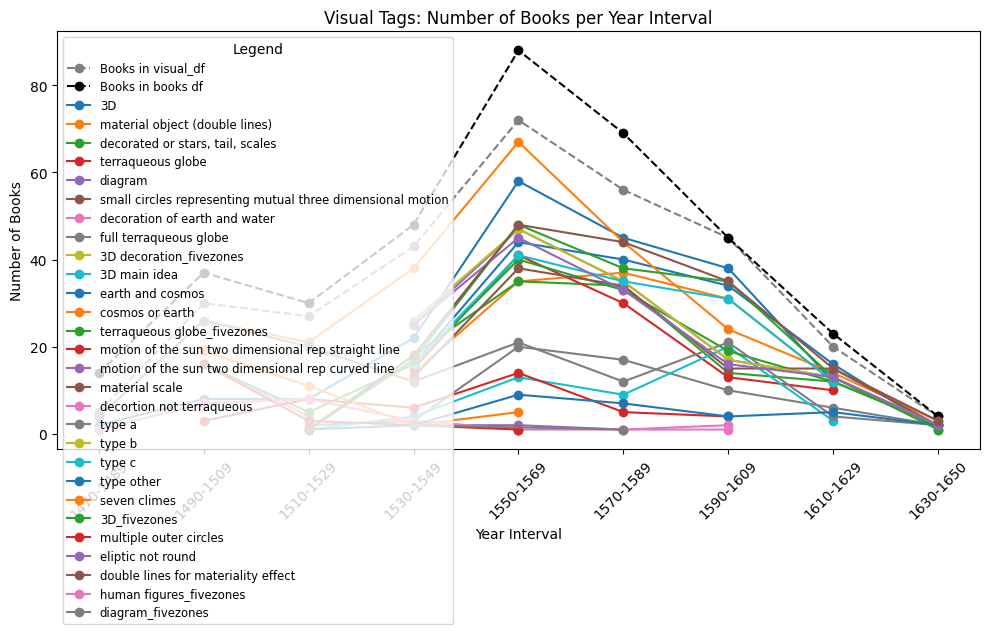

In [46]:

plt.figure(figsize=(10, 6))

# Define visual tag columns
defined_columns = [
    '3D',
    'human figures',
    'material object (double lines)',
    # 'multiple moments',
    # 'multiple perspectives',
    # 'color',
    # 'multiple circles',
    'decorated or stars, tail, scales',
    # 'picture',
    'terraqueous globe',
    'diagram',
    'small circles representing mutual three dimensional motion',
    # 'symbol',
    # '3D decoration',
    # '3D main point',
    # 'Unnamed: 3',
    # '3D_geo',
    # 'human figures_geo',
    'material representation',
    'diagram_geo',
    'decoration of earth and water',
    'full terraqueous globe',
    '3D decoration_fivezones',
    '3D main idea',
    'earth and cosmos',
    'cosmos or earth',
    'terraqueous globe_fivezones',
    'motion of the sun two dimensional rep straight line',
    'motion of the sun two dimensional rep curved line',
    'material scale',
    'decortion not terraqueous',
    'type a',
    'type b',
    'type c',
    'type other',
    'seven climes',
    '3D_fivezones',
    'multiple outer circles',
    'eliptic not round',
    'double lines for materiality effect',
    'human figures_fivezones',
    'diagram_fivezones'
    ]

# Define sorted intervals
intervals = sorted(visual_df['year_interval'].dropna().unique())

# 1. Total unique books per interval in visual_df
unique_books_visual = (
    visual_df.groupby('year_interval', observed=False)['book']
    .nunique()
    .reindex(intervals, fill_value=0)
)

# 2. Total unique books per interval in books df
unique_books_from_books_df = (
    books.groupby('year_interval', observed=False)['book']
    .nunique()
    .reindex(intervals, fill_value=0)
)

# Plot total lines
plt.plot(intervals, unique_books_visual.values, label='Books in visual_df', marker='o', color='grey', linestyle='--')
plt.plot(intervals, unique_books_from_books_df.values, label='Books in books df', marker='o', color='black', linestyle='--')

# 3. Plot each visual tag with zero-excluding logic
for col in defined_columns:
    books_with_tag = (
        visual_df[visual_df[col] == 'yes']
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .reindex(intervals, fill_value=0)
    )

    # Filter out intervals with zero values
    non_zero_intervals = [interval for interval, val in zip(intervals, books_with_tag.values) if val > 0]
    non_zero_values = [val for val in books_with_tag.values if val > 0]

    if non_zero_values:
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=col)

# Final formatting
plt.title('Visual Tags: Number of Books per Year Interval')
plt.xlabel('Year Interval')
plt.ylabel('Number of Books')
plt.xticks(rotation=45)
plt.legend(title='Legend', fontsize='small', title_fontsize='medium')
plt.tight_layout()

# Save and show
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/xxx.png', dpi=300)
plt.show()


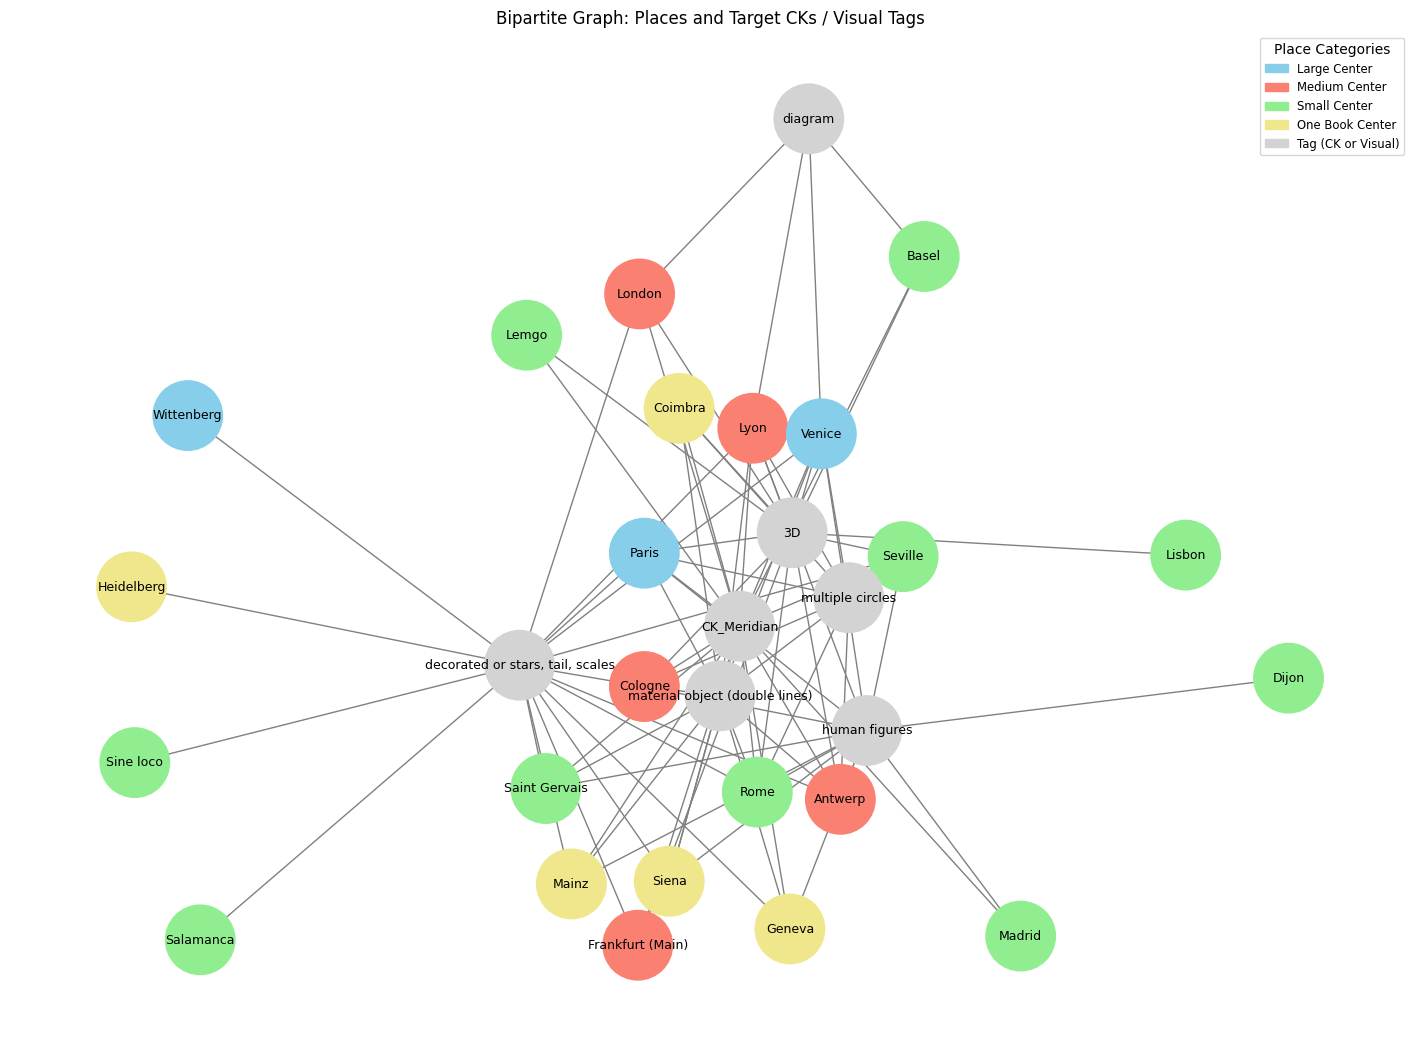

In [72]:

# === Assumes this is already defined earlier ===
target_cks = [
'CK_Meridian',
# 'CK_Horizon',
# 'CK_Elevation of the Pole',
]

# === Step 1: Visual tags ===
defined_columns = [
'3D', 
'human figures',
'material object (double lines)', 
# 'multiple moments',
# 'multiple perspectives', 
# 'color', 
'multiple circles',
'decorated or stars, tail, scales', 
# # 'picture', 
# 'terraqueous globe',
'diagram', 
# # 'small circles representing mutual three dimensional motion',
# # 'symbol', 
# '3D decoration',
# '3D main point', 
# # '3D_geo',
# # 'human figures_geo', 
# # 'material representation',
# 'diagram_geo'

]

# === Step 2: Build edge list ===
edges = []
places = visual_df['place'].dropna().unique().tolist()

for place in places:
    place_data = visual_df[visual_df['place'] == place]

    # Add CKs only if in target_cks
    for cks in target_cks:
        if (place_data['cks'] == cks).any():
            edges.append((place, cks))

    # Add visual tag edges
    for tag in defined_columns:
        if (place_data[tag] == 'yes').any():
            edges.append((place, tag))

# Optional: inspect edge structure
# edges_df = pd.DataFrame(edges, columns=['place', 'tag'])
# print(edges_df)

# === Step 3: Unique node sets ===
places = list(set(edge[0] for edge in edges))
tags = list(set(edge[1] for edge in edges))

# === Step 4: Color by place category ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
existing_categories = visual_df['place_category'].dropna().unique()
ordered_present_categories = [cat for cat in ordered_categories if cat in existing_categories]

color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
category_color_map = {
    cat: color for cat, color in zip(ordered_present_categories, color_palette)
}

place_color_map = {}
for place in places:
    cat_series = visual_df[visual_df['place'] == place]['place_category'].dropna()
    category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
    place_color_map[place] = category_color_map.get(category, 'gray')

# === Step 5: Build the graph ===
G = nx.Graph()
G.add_nodes_from(places, bipartite=0)
G.add_nodes_from(tags, bipartite=1)
G.add_edges_from(edges)

# === Step 6: Assign node colors ===
node_colors = [
    place_color_map[node] if node in places else 'lightgray'
    for node in G.nodes()
]

# === Step 7: Draw ===
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=2500,
    font_size=9
)

# === Step 8: Legend ===
legend_handles = [
    mpatches.Patch(color=category_color_map[cat], label=cat)
    for cat in ordered_present_categories
]
legend_handles.append(mpatches.Patch(color='lightgray', label='Tag (CK or Visual)'))

plt.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)
plt.title("Bipartite Graph: Places and Target CKs / Visual Tags")

# === Step 9: Save or show ===
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/2.3_network.png', dpi=300)
plt.show()


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_94083/2760564538.py:121: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0.07, 1, 0.95])  # leave space for legend and title


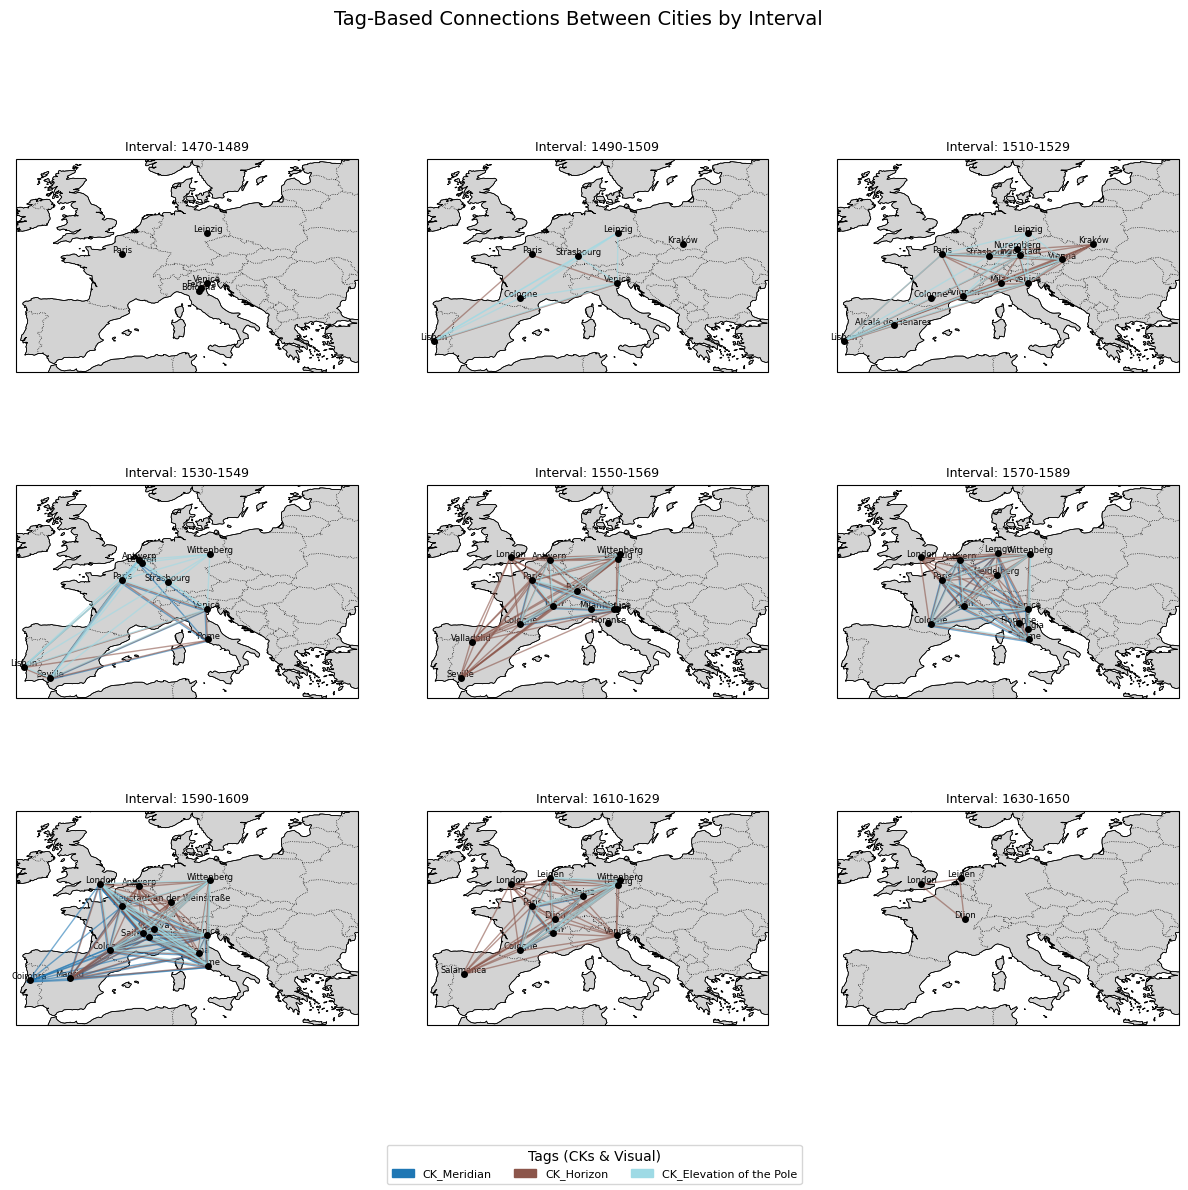

In [52]:
#geotemporal with all cities of the corpus 


# Replace with your actual CK list
target_cks = [
  'CK_Meridian',
'CK_Horizon',
'CK_Elevation of the Pole',
]

# Color map
all_tags = target_cks
colors = plt.cm.tab20(np.linspace(0, 1, len(all_tags)))
tag_color_map = dict(zip(all_tags, colors))

# Bounding box
min_lon, max_lon = -10, 30
min_lat, max_lat = 35, 60

# Sorted time intervals
sorted_intervals = sorted(filtered_df['year_interval'].dropna().unique())

# === Function to plot one interval ===
def plot_tag_lines_on_ax(ax, interval):
    df_interval = filtered_df[filtered_df['year_interval'] == interval].copy()

    gdf = gpd.GeoDataFrame(
        df_interval,
        geometry=gpd.points_from_xy(df_interval['longitude'], df_interval['latitude']),
        crs="EPSG:4326"
    ).dropna(subset=['longitude', 'latitude'])

    # All cities from full df
    all_cities_df = df[df['year_interval'] == interval].copy()
    all_cities_df = all_cities_df.dropna(subset=['longitude', 'latitude'])
    all_cities_df = all_cities_df.drop_duplicates(subset=['place'])

    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray', linewidth=0.5)

    jitter_amount = 0.12

    for tag_index, tag in enumerate(all_tags):
        if tag in target_cks:
            tagged_cities = gdf[gdf['cks'] == tag]
        else:
            tagged_cities = gdf[gdf[tag] == 'yes']

        tagged_coords = tagged_cities[['place', 'longitude', 'latitude']].drop_duplicates()
        jitter_offset = (tag_index % 5 - 2) * jitter_amount

        for (i1, row1), (i2, row2) in combinations(tagged_coords.iterrows(), 2):
            if (row1['longitude'] == row2['longitude']) and (row1['latitude'] == row2['latitude']):
                continue

            ax.plot(
                [row1['longitude'] + jitter_offset, row2['longitude'] + jitter_offset],
                [row1['latitude'] + jitter_offset, row2['latitude'] + jitter_offset],
                color=tag_color_map[tag],
                linewidth=1,
                alpha=0.6,
                transform=ccrs.PlateCarree(),
                zorder=4
            )

    # Plot all city dots
    for _, row in all_cities_df.iterrows():
        ax.plot(
            row['longitude'], row['latitude'],
            marker='o', color='black', markersize=4,
            transform=ccrs.PlateCarree(),
            zorder=5
        )
        ax.text(
            row['longitude'], row['latitude'] + 0.15,
            row['place'], fontsize=6, ha='center',
            transform=ccrs.PlateCarree()
        )

    ax.set_title(f"Interval: {interval}", fontsize=9)


# === Plotting pages in 3x3 grid ===
per_page = 9
num_pages = int(np.ceil(len(sorted_intervals) / per_page))

for page in range(num_pages):
    start = page * per_page
    end = min((page + 1) * per_page, len(sorted_intervals))
    intervals_subset = sorted_intervals[start:end]

    fig, axs = plt.subplots(
        3, 3,
        figsize=(15, 12),  # enough space, but tight
        subplot_kw={'projection': ccrs.PlateCarree()}
    )
    axs = axs.flatten()

    for i, interval in enumerate(intervals_subset):
        plot_tag_lines_on_ax(axs[i], interval)

    for j in range(len(intervals_subset), 9):
        axs[j].set_visible(False)

    # Shared legend
    legend_handles = [
        mpatches.Patch(color=color, label=tag) for tag, color in tag_color_map.items()
    ]
    fig.legend(
        handles=legend_handles,
        loc='lower center',
        ncol=4,
        fontsize=8,
        title='Tags (CKs & Visual)'
    )

    # Title and layout
    plt.suptitle("Tag-Based Connections Between Cities by Interval", fontsize=14)
    plt.tight_layout(rect=[0, 0.07, 1, 0.95])  # leave space for legend and title

    # plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.9_geotemporal.png', dpi=300)

    
    plt.show()

